In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [3]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:21<00:00, 135MB/s]



In [4]:
!unzip new-plant-diseases-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/273a7a9e-18be-4b6a-976a-fa5ffd69b731___RS_HL 4366_90deg.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_90deg.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_new30degFlipLR.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/27c2aaa4-de4b-4fb1-ba8d-14d4b24b2afa___RS_HL 4665.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/27c2aaa4-de4b-4fb1-ba8d-14d4b24b2afa___RS_HL 4665_270deg.JPG  
  inflating: new plant diseases dataset(augmented)/New 

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
print(tf.__version__)

2.20.0


In [6]:
training_set = tf.keras.utils.image_dataset_from_directory(
        '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
        labels="inferred",
        label_mode="categorical",
        class_names=None,
        color_mode="rgb",
        batch_size=32,
        image_size=(128,128),
        shuffle=True,
        seed=None,
        validation_split=None,
        subset=None,
        interpolation="bilinear",
        follow_links=False,
       crop_to_aspect_ratio=False

)

validating_set = tf.keras.utils.image_dataset_from_directory(
    '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
    labels="inferred",
     label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128,128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False



)



Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.


In [7]:
for x,y in training_set:
  print(x,x.shape)
  print(y,y.shape)
  break

tf.Tensor(
[[[[149.25 124.    94.75]
   [143.5  115.    84.75]
   [219.75 188.   155.25]
   ...
   [107.5  154.5  100.5 ]
   [102.   149.    95.  ]
   [101.5  145.5   94.5 ]]

  [[138.25 113.5   89.25]
   [ 60.5   34.75  13.25]
   [ 96.5   69.5   43.  ]
   ...
   [103.25 150.25  96.25]
   [ 96.25 143.25  91.25]
   [ 94.5  138.5   87.5 ]]

  [[ 88.75  68.    54.5 ]
   [ 34.75  15.5    2.  ]
   [ 48.25  29.75   3.75]
   ...
   [ 96.5  143.5   89.5 ]
   [ 91.   135.    84.  ]
   [ 88.25 130.25  80.25]]

  ...

  [[130.   174.    76.75]
   [140.   184.    86.25]
   [142.5  187.25  87.  ]
   ...
   [175.75 201.   152.75]
   [186.25 201.75 160.5 ]
   [183.5  192.5  155.5 ]]

  [[136.25 180.25  82.25]
   [150.25 195.    94.75]
   [131.5  176.5   75.5 ]
   ...
   [156.5  181.   126.5 ]
   [173.   185.25 141.25]
   [120.   126.    85.25]]

  [[142.75 187.75  86.75]
   [138.5  183.5   82.5 ]
   [127.   172.    71.  ]
   ...
   [139.75 163.75 105.75]
   [124.5  134.75  87.25]
   [ 40.25  42.     

In [8]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [9]:
model=Sequential()
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2));

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2));

In [11]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2));

In [12]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2));

In [13]:
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(units=1024,activation='relu'))
model.add(Dropout(0.4))

In [14]:
#output Layer
model.add(Dense(units=38,activation='softmax'))

In [15]:
model.compile(optimizer=tf.keras.optimizers.Adam(
      learning_rate=0.0001
),loss='categorical_crossentropy',metrics=['accuracy'])

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     9,438,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        38,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,649,414 (40.62 MB)

 Trainable params: 10,649,414 (40.62 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
training_history=model.fit(training_set,validation_data=validating_set,epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 136s 55ms/step - accuracy: 0.5190 - loss: 1.6500 - val_accuracy: 0.7863 - val_loss: 0.6703
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 114s 52ms/step - accuracy: 0.8150 - loss: 0.5747 - val_accuracy: 0.8905 - val_loss: 0.3397
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 124s 56ms/step - accuracy: 0.8713 - loss: 0.3935 - val_accuracy: 0.9150 - val_loss: 0.2549
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 124s 56ms/step - accuracy: 0.8879 - loss: 0.3433 - val_accuracy: 0.9170 - val_loss: 0.2621
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 113s 52ms/step - accuracy: 0.9044 - loss: 0.2973 - val_accuracy: 0.9074 - val_loss: 0.2934
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 152s 56ms/step - accuracy: 0.9110 - loss: 0.2784 - val_accuracy: 0.9247 - val_loss: 0.2355
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 114s 52ms/step - accuracy: 0.9152 - loss: 0.2645 - val_accuracy: 0.9128 - val_loss: 0.2735
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 123s 56ms/step - accuracy: 

## 10. Model Evaluating

In [18]:
#model evaluating on training set
train_loss,train_acc=model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 48s 22ms/step - accuracy: 0.9743 - loss: 0.0833


In [19]:
print(train_loss,train_acc)

0.08326145261526108 0.9742940664291382


In [20]:
# model evaluating on validating set
val_loss,val_acc=model.evaluate(validating_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.9402 - loss: 0.1966


In [21]:
print(val_loss,val_acc)

0.1965993344783783 0.9402458667755127


## Saving model

In [22]:
model.save("training_model.keras")

In [23]:
training_history.history

{'accuracy': [0.5189985036849976,
  0.8150224089622498,
  0.8712568283081055,
  0.8879294395446777,
  0.9043744206428528,
  0.9110178351402283,
  0.9152286648750305,
  0.9061810970306396,
  0.9160110950469971,
  0.919738233089447],
 'loss': [1.650006890296936,
  0.5746732354164124,
  0.3934898376464844,
  0.3433349132537842,
  0.2973025441169739,
  0.27841171622276306,
  0.26454243063926697,
  0.3007510006427765,
  0.2649317979812622,
  0.25812840461730957],
 'val_accuracy': [0.7862508296966553,
  0.8904507160186768,
  0.9150353074073792,
  0.9170271158218384,
  0.9074094891548157,
  0.9247097373008728,
  0.9128158688545227,
  0.9278397560119629,
  0.9224334359169006,
  0.9402458667755127],
 'val_loss': [0.6703291535377502,
  0.33967047929763794,
  0.2549155056476593,
  0.262129545211792,
  0.2934368848800659,
  0.23546242713928223,
  0.2735370695590973,
  0.23119880259037018,
  0.24801798164844513,
  0.1965993344783783]}

## Recording History in json

In [24]:
import json
with open("training_his.json","w") as f:
  json.dump(training_history.history,f)

In [25]:
training_history.history['accuracy']

[0.5189985036849976,
 0.8150224089622498,
 0.8712568283081055,
 0.8879294395446777,
 0.9043744206428528,
 0.9110178351402283,
 0.9152286648750305,
 0.9061810970306396,
 0.9160110950469971,
 0.919738233089447]

## Accuracy Visualization

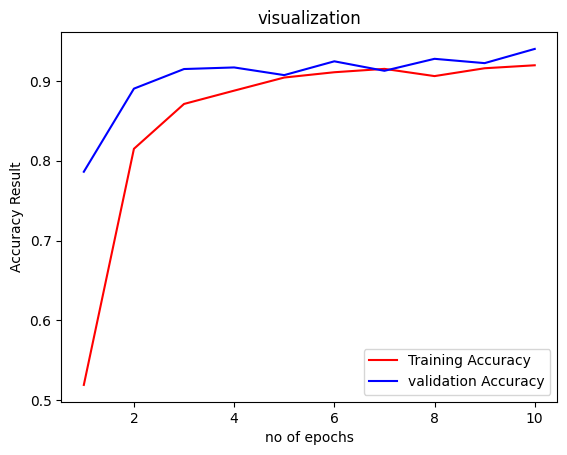

In [26]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='validation Accuracy')
plt.xlabel('no of epochs')
plt.ylabel('Accuracy Result')
plt.title('visualization')
plt.legend()
plt.show()

In [37]:
class_name = validating_set.class_names

In [38]:
test_set=tf.keras.utils.image_dataset_from_directory(
          '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
          labels="inferred",
          label_mode="categorical",
          class_names=None,
           color_mode="rgb",
            batch_size=32,
           image_size=(128,128),
          shuffle=False,
          seed=None,
          validation_split=None,
          subset=None,
          interpolation="bilinear",
       follow_links=False,
         crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


In [28]:
y_pred = model.predict(test_set)
y_pred,y_pred.shape

550/550 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step


(array([[9.98326361e-01, 9.20879596e-04, 1.51769740e-07, ...,
         6.18600005e-10, 1.05015024e-10, 6.46731513e-09],
        [9.99994040e-01, 2.96071335e-07, 6.69108380e-11, ...,
         6.88737587e-13, 2.06230215e-12, 4.87860891e-14],
        [9.99472022e-01, 2.84565863e-06, 1.30875879e-08, ...,
         4.00619177e-10, 1.39543613e-10, 3.96592981e-09],
        ...,
        [4.11636458e-09, 1.52692475e-13, 8.26647266e-08, ...,
         6.39987491e-07, 8.21872259e-09, 9.99430597e-01],
        [2.97210952e-14, 2.57526640e-23, 2.96976189e-15, ...,
         1.00242825e-09, 2.09803245e-17, 9.99999881e-01],
        [1.43960348e-14, 1.66109249e-15, 3.08047163e-15, ...,
         9.06871453e-12, 2.31963337e-10, 9.98554051e-01]], dtype=float32),
 (17572, 38))

In [29]:
predicted_categories=tf.argmax(y_pred,axis=1)

In [30]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [31]:
true_categories=tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [32]:
y_true=tf.argmax(true_categories,axis=1)
y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [41]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.94      0.94      0.94       504
                                 Apple___Black_rot       0.99      0.97      0.98       497
                          Apple___Cedar_apple_rust       0.96      0.95      0.96       440
                                   Apple___healthy       0.91      0.93      0.92       502
                               Blueberry___healthy       0.96      0.94      0.95       454
          Cherry_(including_sour)___Powdery_mildew       0.97      0.98      0.98       421
                 Cherry_(including_sour)___healthy       0.92      0.99      0.96       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.94      0.87      0.90       410
                       Corn_(maize)___Common_rust_       1.00      0.97      0.98       477
               Corn_(maize)___Northern_Leaf_Blight       0.89      0.96      0.

In [42]:
cm=confusion_matrix(y_true,predicted_categories)
cm


array([[474,   3,   0, ...,   0,   0,   1],
       [  4, 482,   1, ...,   0,   0,   0],
       [  2,   0, 420, ...,   1,   0,   2],
       ...,
       [  0,   0,   1, ..., 476,   0,   0],
       [  0,   0,   1, ...,   1, 437,   0],
       [  0,   0,   0, ...,   0,   0, 466]])

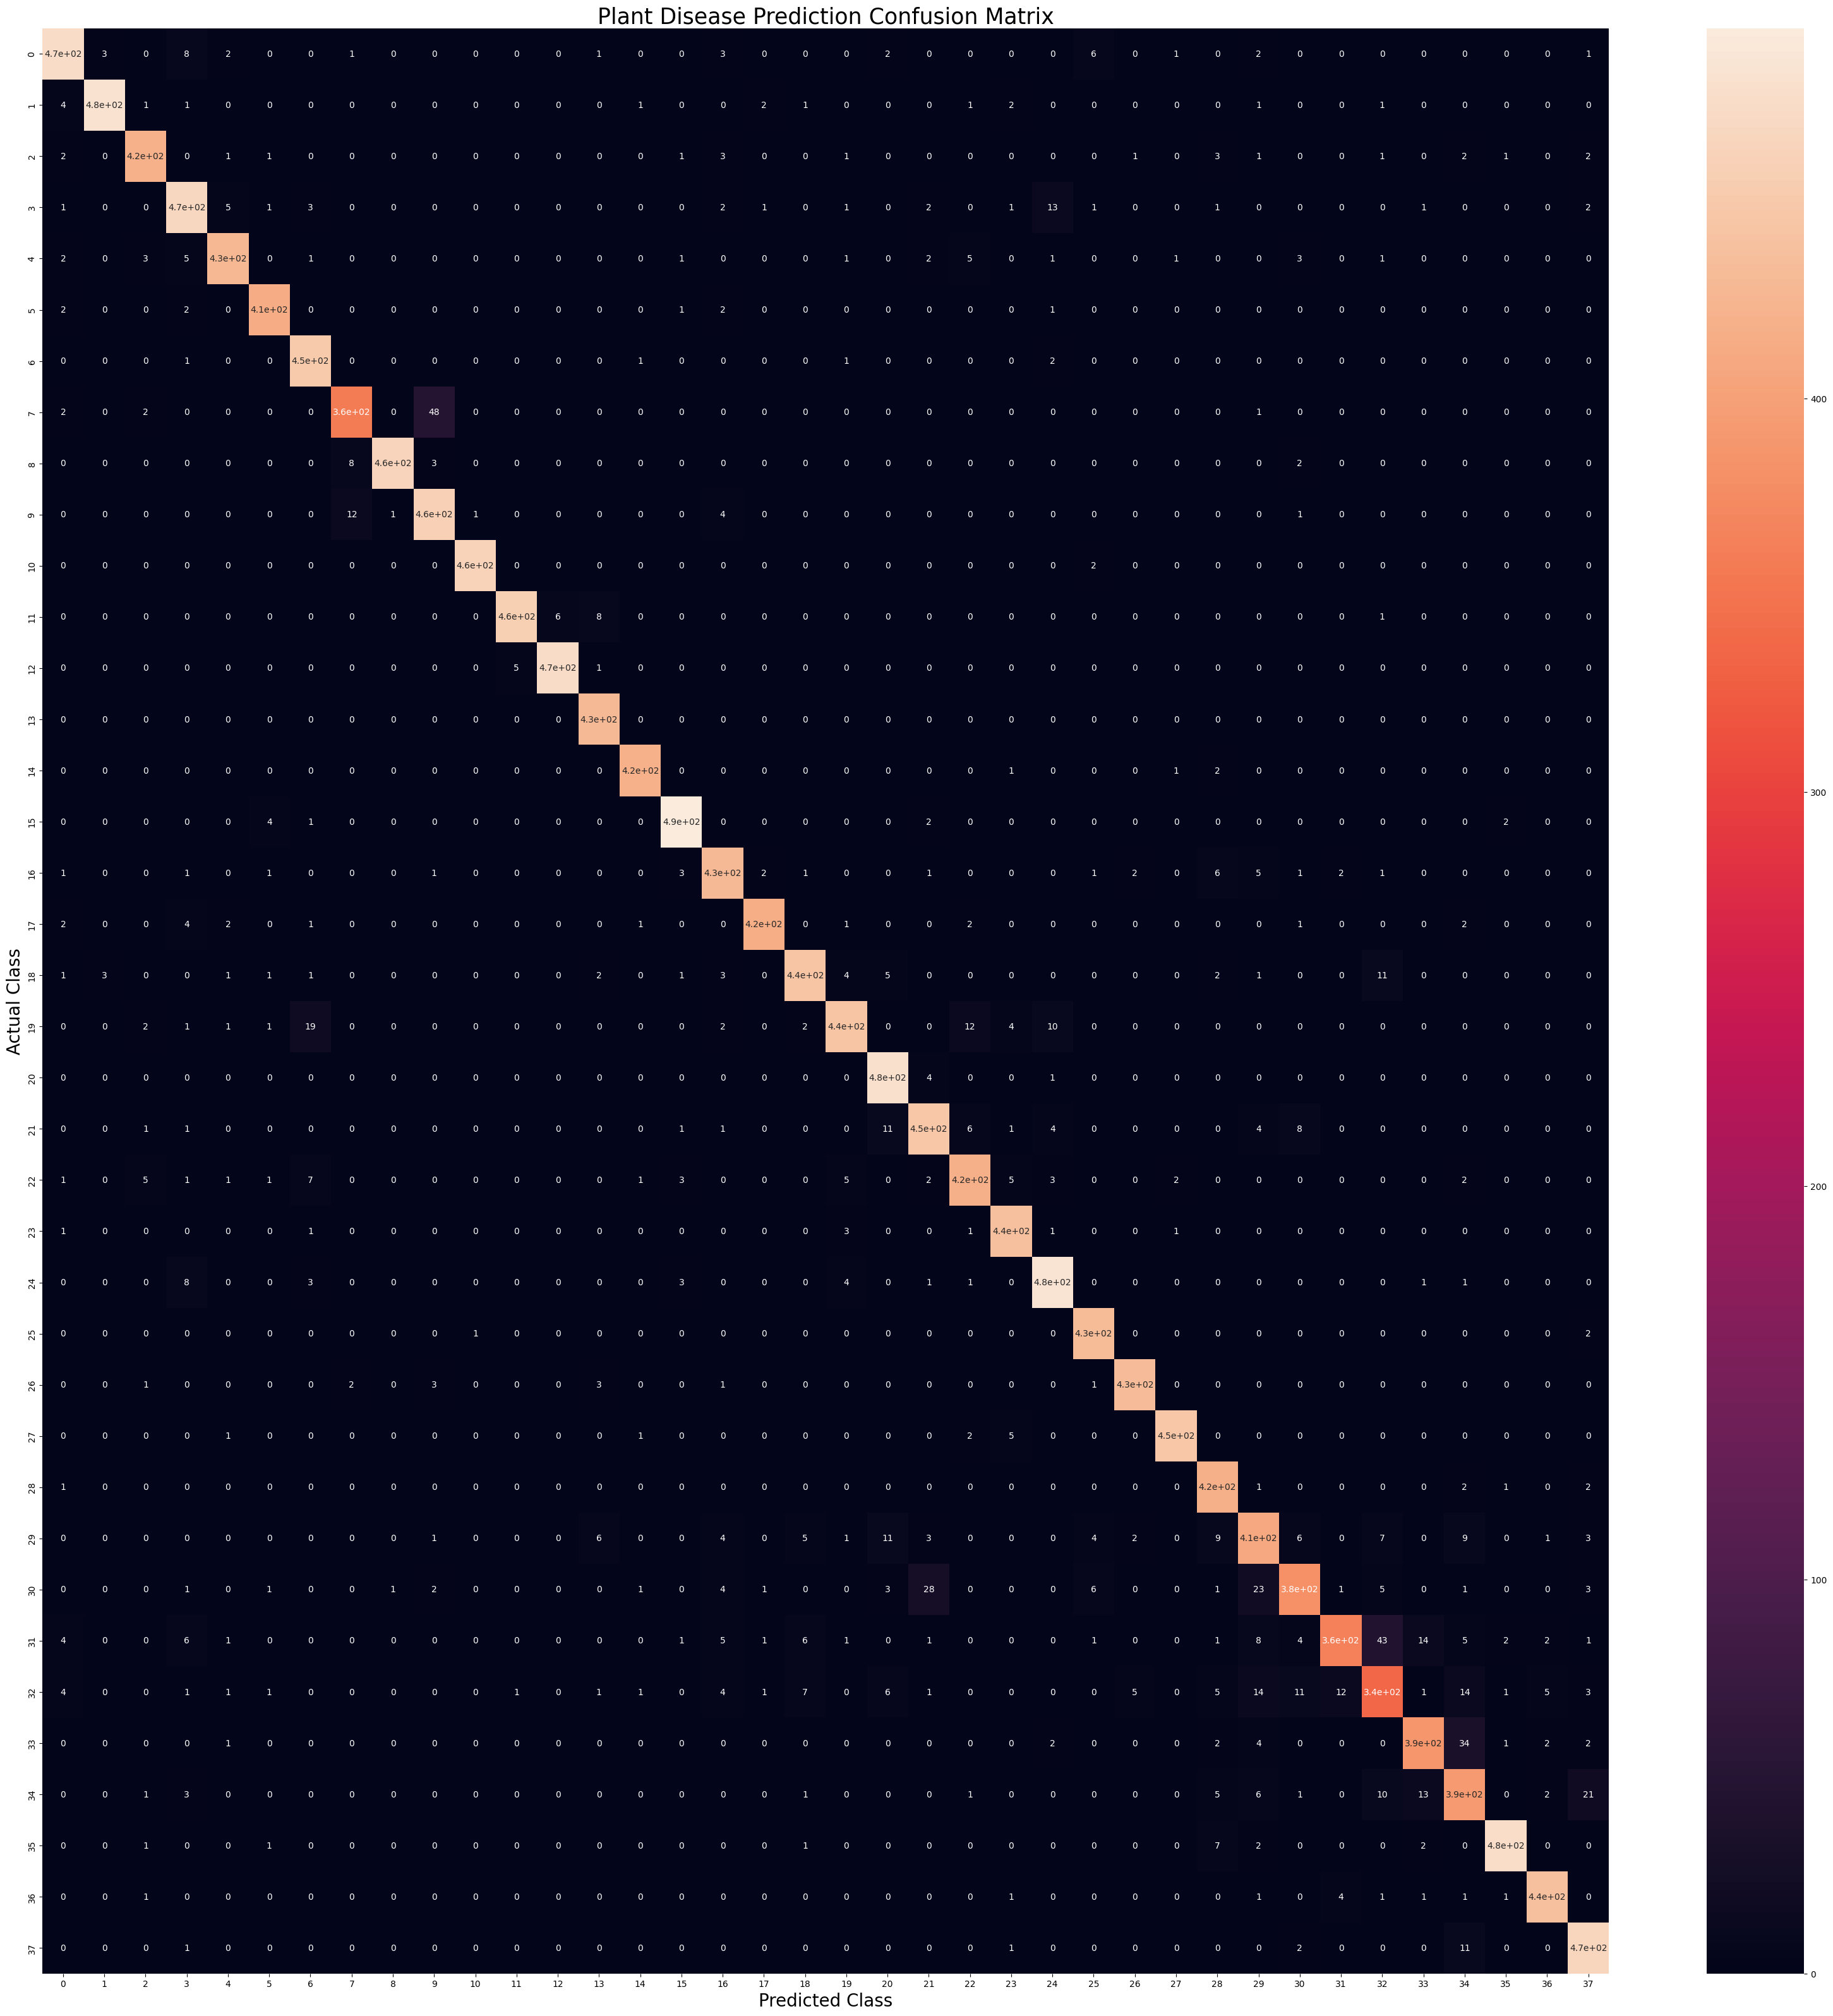

In [43]:


plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()

